# Time series Weather Forecasting

In [2]:
# time series library imports
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
# managing figure size in the beginning of the code
mpl.rcParams['figure.figsize'] = (15, 6)
mpl.rcParams['axes.grid'] = False

## Import weather dataset

In [12]:
# import the dataset
zip_path = tf.keras.utils.get_file(
    origin = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname = 'jena_climate_2009_2016.csv.zip',
    extract = True)
csv_path, _ = os.path.splitext(zip_path)

In [14]:
csv_path = os.path.join(csv_path, "jena_climate_2009_2016.csv") if os.path.isdir(csv_path) else csv_path
# read the data in pandas dataframe
df = pd.read_csv(csv_path)
# write the data to a csv file
df.to_csv('../data/jena_climate_2009_2016.csv')

In [15]:
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [18]:
print("Shape of the dataset:", df.shape)
print("Total number of data points:", 420551 * 15)
df.info


Shape of the dataset: (420551, 15)
Total number of data points: 6308265


<bound method DataFrame.info of                   Date Time  p (mbar)  ...  max. wv (m/s)  wd (deg)
0       01.01.2009 00:10:00    996.52  ...           1.75     152.3
1       01.01.2009 00:20:00    996.57  ...           1.50     136.1
2       01.01.2009 00:30:00    996.53  ...           0.63     171.6
3       01.01.2009 00:40:00    996.51  ...           0.50     198.0
4       01.01.2009 00:50:00    996.51  ...           0.63     214.3
...                     ...       ...  ...            ...       ...
420546  31.12.2016 23:20:00   1000.07  ...           1.52     240.0
420547  31.12.2016 23:30:00    999.93  ...           1.92     234.3
420548  31.12.2016 23:40:00    999.82  ...           2.00     215.2
420549  31.12.2016 23:50:00    999.81  ...           2.16     225.8
420550  01.01.2017 00:00:00    999.82  ...           1.96     184.9

[420551 rows x 15 columns]>

In [23]:
# Reverse teh order from columns to rows and display the summary statistics of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
p (mbar),420551.0,989.212776,8.358481,913.60,984.20,989.58,994.72,1015.35
T (degC),420551.0,9.450147,8.423365,-23.01,3.36,9.42,15.47,37.28
Tpot (K),420551.0,283.492743,8.504471,250.60,277.43,283.47,289.53,311.34
Tdew (degC),420551.0,4.955854,6.730674,-25.01,0.24,5.22,10.07,23.11
rh (%),420551.0,76.008259,16.476175,12.95,65.21,79.30,89.40,100.00
VPmax (mbar),420551.0,13.576251,7.739020,0.95,7.78,11.82,17.60,63.77
VPact (mbar),420551.0,9.533756,4.184164,0.79,6.21,8.86,12.35,28.32
VPdef (mbar),420551.0,4.042412,4.896851,0.00,0.87,2.19,5.30,46.01
sh (g/kg),420551.0,6.022408,2.656139,0.50,3.92,5.59,7.80,18.13
H2OC (mmol/mol),420551.0,9.640223,4.235395,0.80,6.29,8.96,12.49,28.82


In [25]:
# print all the columns
pd.set_option('display.max_rows', None)
df.head(20)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
5,01.01.2009 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
6,01.01.2009 01:10:00,996.50,-7.62,265.81,-8.30,94.8,3.44,3.26,0.18,2.04,3.27,1305.68,0.18,0.63,166.5
7,01.01.2009 01:20:00,996.50,-7.62,265.81,-8.36,94.4,3.44,3.25,0.19,2.03,3.26,1305.69,0.19,0.50,118.6
8,01.01.2009 01:30:00,996.50,-7.91,265.52,-8.73,93.8,3.36,3.15,0.21,1.97,3.16,1307.17,0.28,0.75,188.5
9,01.01.2009 01:40:00,996.53,-8.43,264.99,-9.34,93.1,3.23,3.00,0.22,1.88,3.02,1309.85,0.59,0.88,185.0


In [26]:
# select the data based on the Date Time column for every 2 hours interval
# Slice [start:stop:step], starting from index 11 take every 12th record.
df = df[11::12]
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
11,01.01.2009 02:00:00,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
23,01.01.2009 04:00:00,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
35,01.01.2009 06:00:00,997.71,-9.67,263.66,-10.62,92.7,2.93,2.71,0.21,1.69,2.72,1317.71,0.05,0.50,146.0
47,01.01.2009 08:00:00,999.17,-8.10,265.12,-9.05,92.8,3.31,3.07,0.24,1.92,3.08,1311.65,0.72,1.25,213.9
59,01.01.2009 10:00:00,1000.27,-7.04,266.10,-8.17,91.6,3.60,3.30,0.30,2.05,3.29,1307.76,1.45,3.00,292.6


In [28]:
print("Shape of the dataset:", df.shape)
print("Total number of data points:", 35045 * 15)

Shape of the dataset: (35045, 15)
Total number of data points: 525675


In [29]:
date_time = pd.to_datetime(df.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')

In [30]:
df.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
11,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
23,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
35,997.71,-9.67,263.66,-10.62,92.7,2.93,2.71,0.21,1.69,2.72,1317.71,0.05,0.50,146.0
47,999.17,-8.10,265.12,-9.05,92.8,3.31,3.07,0.24,1.92,3.08,1311.65,0.72,1.25,213.9
59,1000.27,-7.04,266.10,-8.17,91.6,3.60,3.30,0.30,2.05,3.29,1307.76,1.45,3.00,292.6


In [31]:
df.columns

Index(['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)',
       'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)'],
      dtype='str')

array([<Axes: xlabel='Date Time'>, <Axes: xlabel='Date Time'>],
      dtype=object)

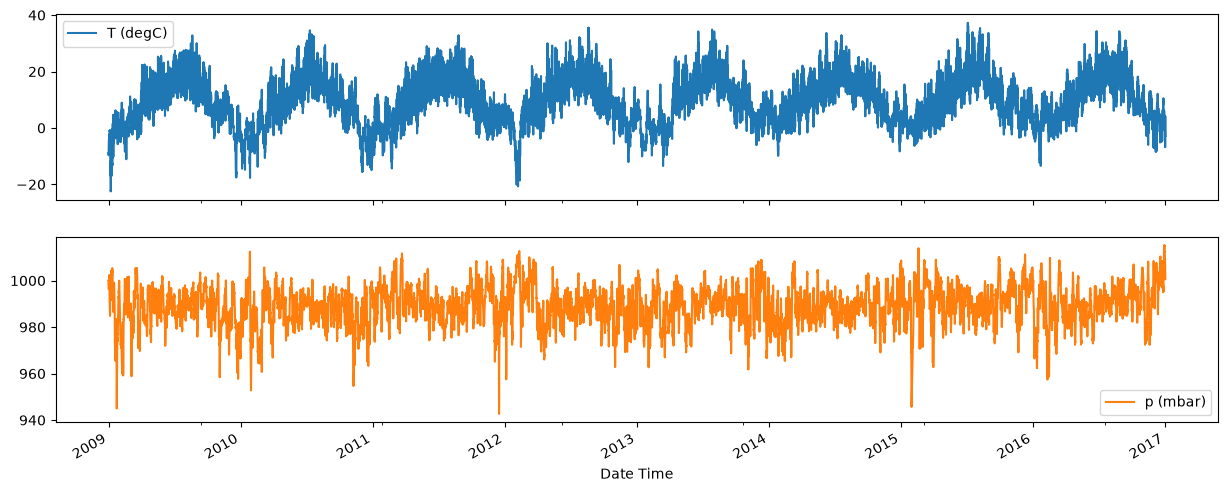

In [32]:
# lets plot the data
plot_cols = ['T (degC)', 'p (mbar)']
plot_features = df[plot_cols]
plot_features.index = date_time
plot_features.plot(subplots=True)

array([<Axes: xlabel='Date Time'>, <Axes: xlabel='Date Time'>],
      dtype=object)

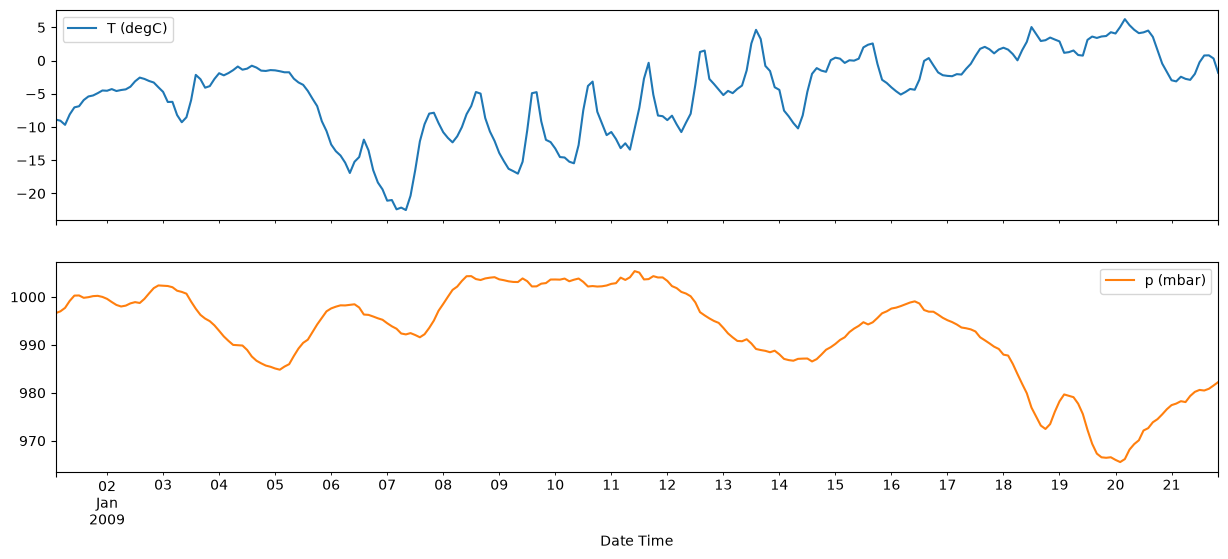

In [33]:
# lets plot only the first 500 hours dataset which is equal to 250 records
plot_cols = ['T (degC)', 'p (mbar)']
plot_features = df[plot_cols][:250]
plot_features.index = date_time[:250]
plot_features.plot(subplots=True)

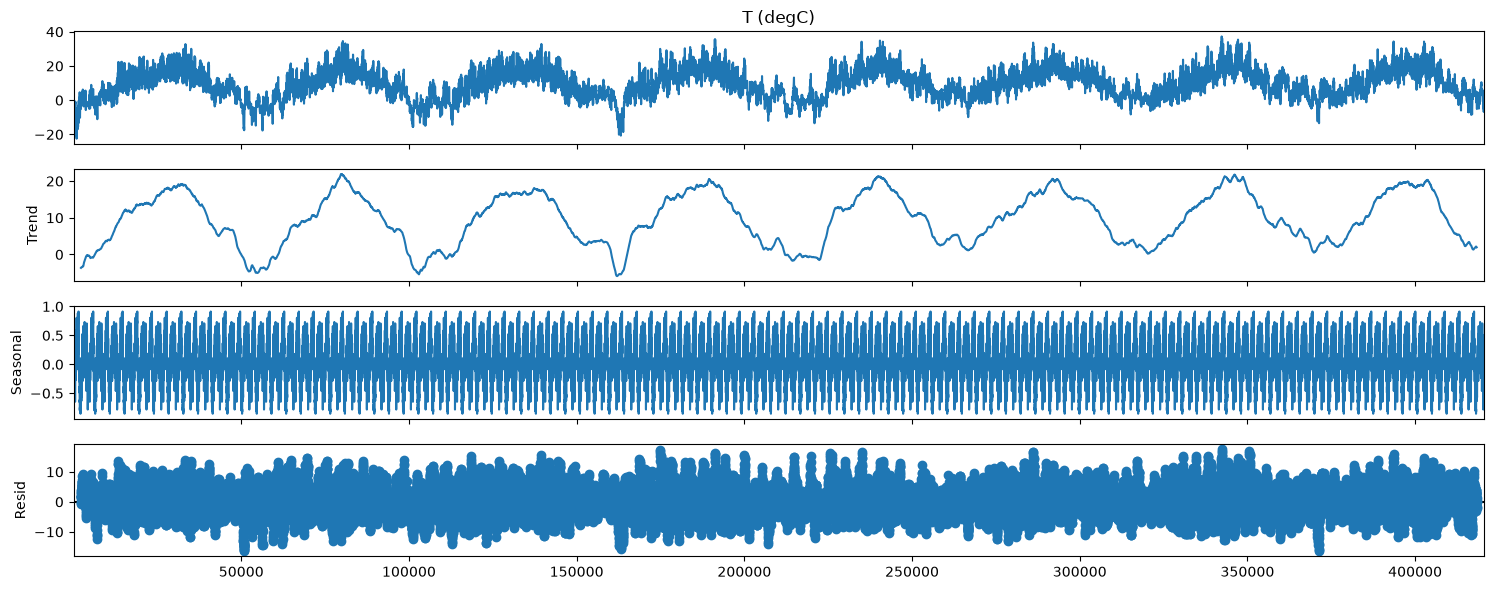

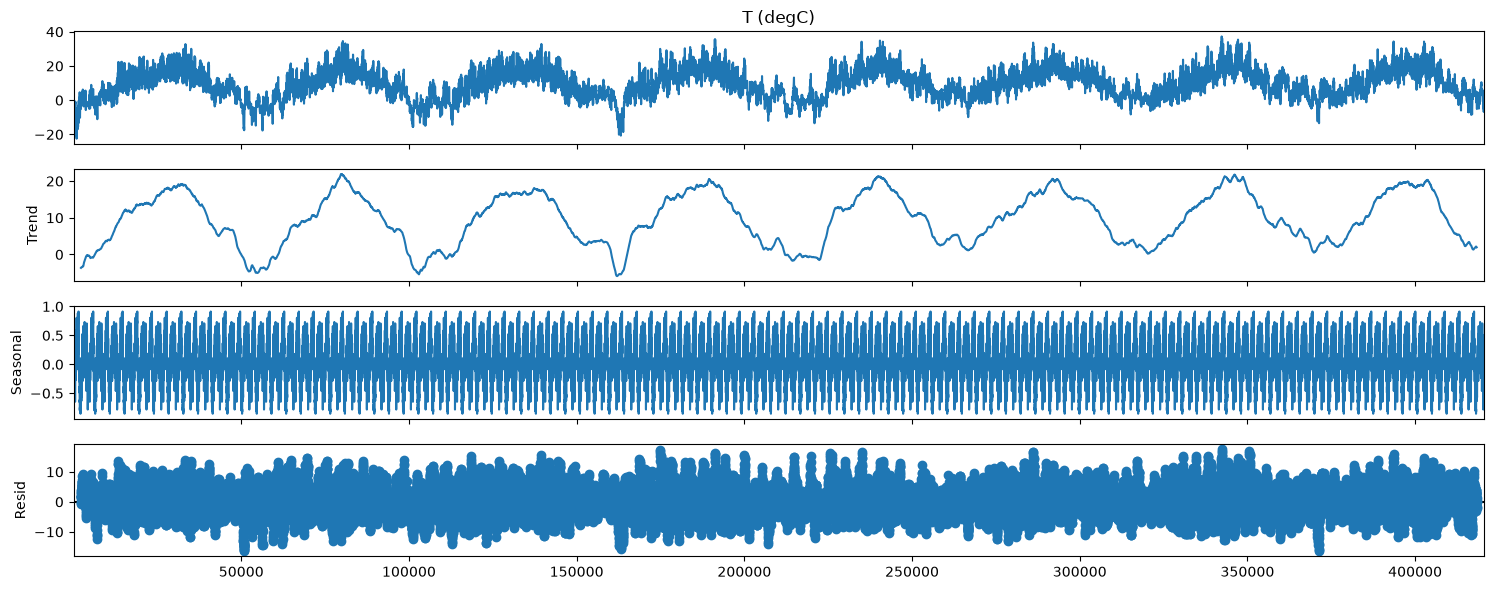

In [34]:
# lets decompose the data into trend, seasonality and noise
# we will use the seasonal_decompose function from statsmodels library
decompose = seasonal_decompose(df['T (degC)'], model='additive', period=365)
decompose.plot()

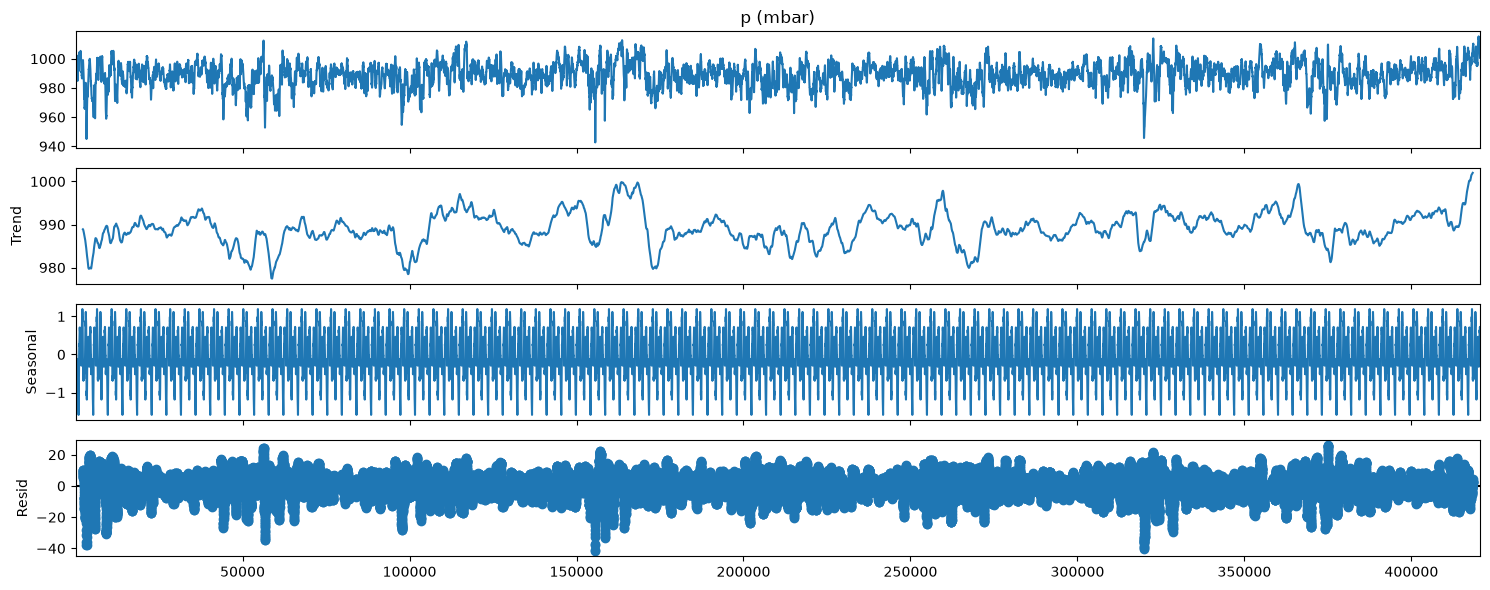

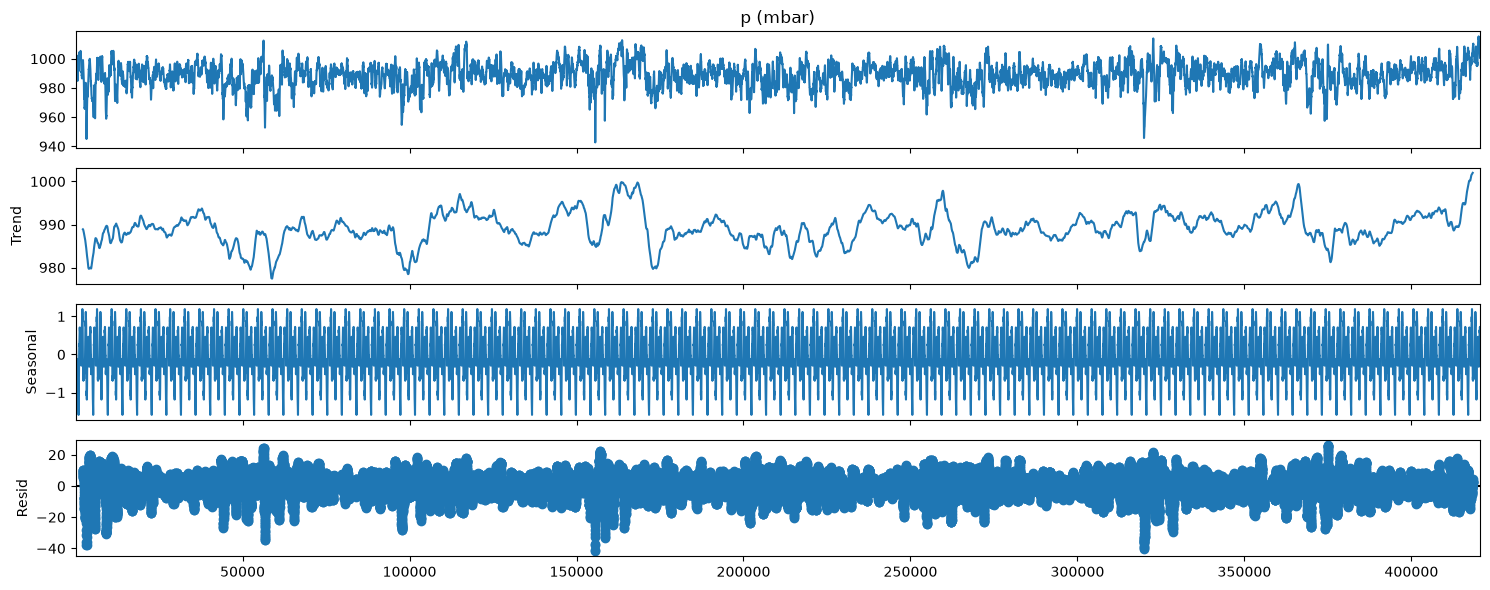

In [35]:
decompose = seasonal_decompose(df['p (mbar)'], model='additive', period=365)
decompose.plot()

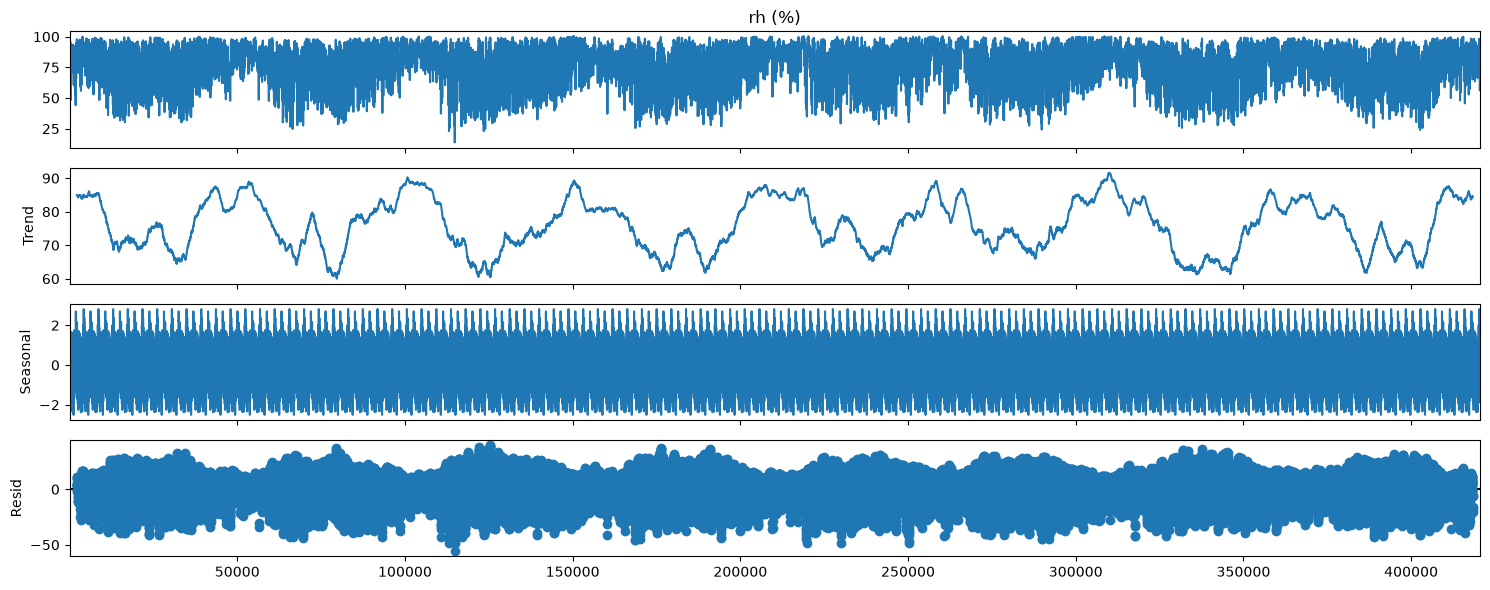

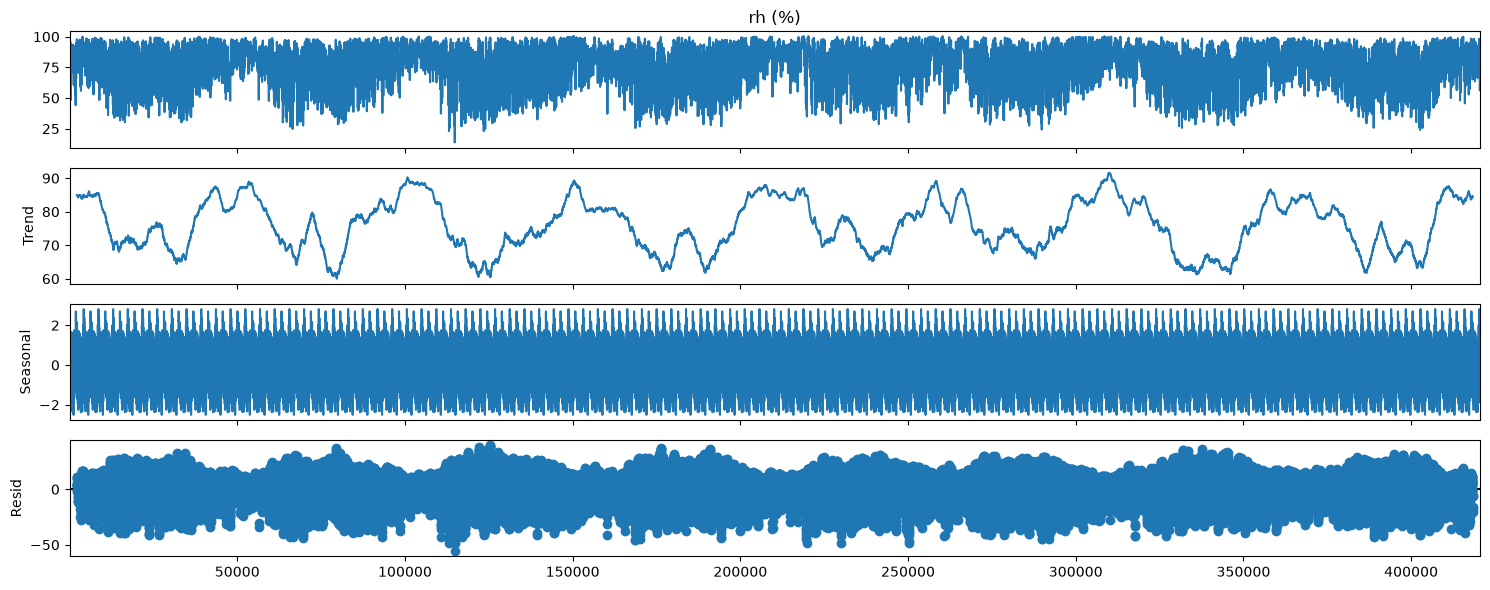

In [36]:
decompose = seasonal_decompose(df['rh (%)'], model='additive', period=365)
decompose.plot()

In [37]:
# lets plot the same plots in plotly
fig = px.line(df, x=date_time, y='T (degC)')
fig.show()
fig = px.line(df, x=date_time, y='p (mbar)')
fig.update_traces(line_color='red')
fig.show()

In [38]:
# clean up the data
# lets check if there are any null values in the dataset
df.isnull().sum()

p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

In [55]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
p (mbar),35045.0,989.213079,8.353850,942.65,984.20,989.57,994.72,1015.16
T (degC),35045.0,9.450335,8.425301,-22.50,3.36,9.43,15.49,37.28
Tpot (K),35045.0,283.492908,8.506133,251.22,277.44,283.48,289.55,311.21
Tdew (degC),35045.0,4.955012,6.729168,-24.55,0.24,5.22,10.08,22.19
rh (%),35045.0,76.006020,16.483440,13.88,65.15,79.30,89.50,100.00
VPmax (mbar),35045.0,13.577314,7.743076,0.99,7.77,11.83,17.62,63.77
VPact (mbar),35045.0,9.532714,4.181965,0.83,6.22,8.86,12.36,26.79
VPdef (mbar),35045.0,4.044542,4.902793,0.00,0.87,2.18,5.30,46.01
sh (g/kg),35045.0,6.021744,2.654692,0.52,3.92,5.60,7.81,17.13
H2OC (mmol/mol),35045.0,9.639148,4.233082,0.83,6.29,8.97,12.49,27.25


In [65]:
df.loc[df['wv (m/s)'] == -9999.0, 'wv (m/s)'] = 0.0
df.loc[df['max. wv (m/s)'] == -9999.0, 'max. wv (m/s)'] = 0.0

In [66]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
p (mbar),35045.0,989.213079,8.353850,942.65,984.20,989.57,994.72,1015.16
T (degC),35045.0,9.450335,8.425301,-22.50,3.36,9.43,15.49,37.28
Tpot (K),35045.0,283.492908,8.506133,251.22,277.44,283.48,289.55,311.21
Tdew (degC),35045.0,4.955012,6.729168,-24.55,0.24,5.22,10.08,22.19
rh (%),35045.0,76.006020,16.483440,13.88,65.15,79.30,89.50,100.00
VPmax (mbar),35045.0,13.577314,7.743076,0.99,7.77,11.83,17.62,63.77
VPact (mbar),35045.0,9.532714,4.181965,0.83,6.22,8.86,12.36,26.79
VPdef (mbar),35045.0,4.044542,4.902793,0.00,0.87,2.18,5.30,46.01
sh (g/kg),35045.0,6.021744,2.654692,0.52,3.92,5.60,7.81,17.13
H2OC (mmol/mol),35045.0,9.639148,4.233082,0.83,6.29,8.97,12.49,27.25


## Modeling

In [54]:
df.shape

(35045, 14)

In [68]:
# split the data into train, validation and test i have 35045 records make 70% for training, 20% for validation and 10% for testing

# 70% of 35045 is 24531
# 20% of 35045 is 7009
# 10% of 35045 is 3505
# total 35045

# train data
train_df = df[:24531]
# validation data
val_df = df[24531:31540]
# test data
test_df = df[31540:]

# lest check the shape of the train, validation and test data
print("Shape of the train data:", train_df.shape)
print("Shape of the validation data:", val_df.shape)
print("Shape of the test data:", test_df.shape)

Shape of the train data: (24531, 14)
Shape of the validation data: (7009, 14)
Shape of the test data: (3505, 14)


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

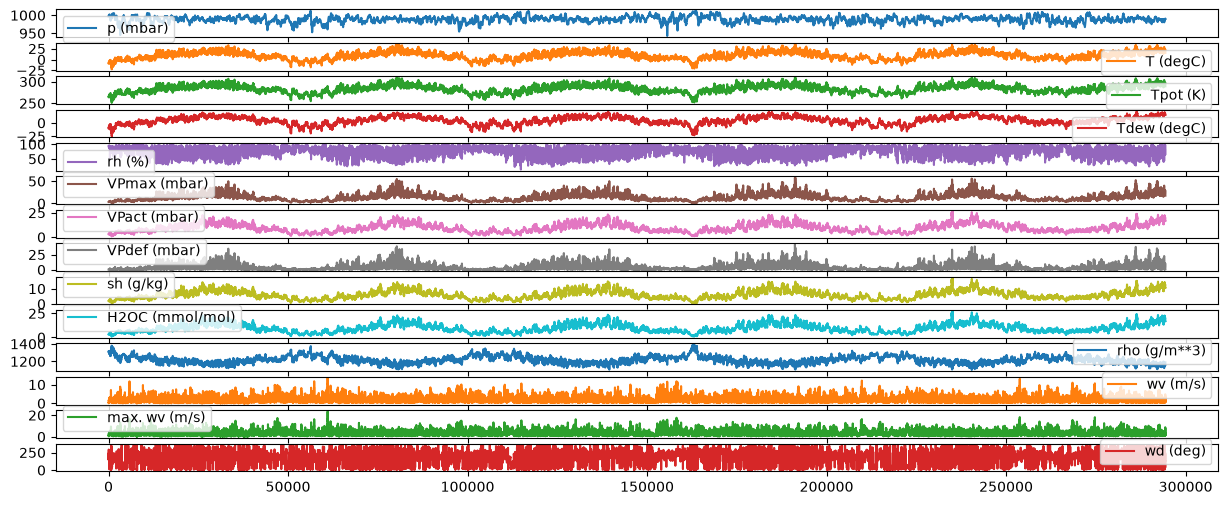

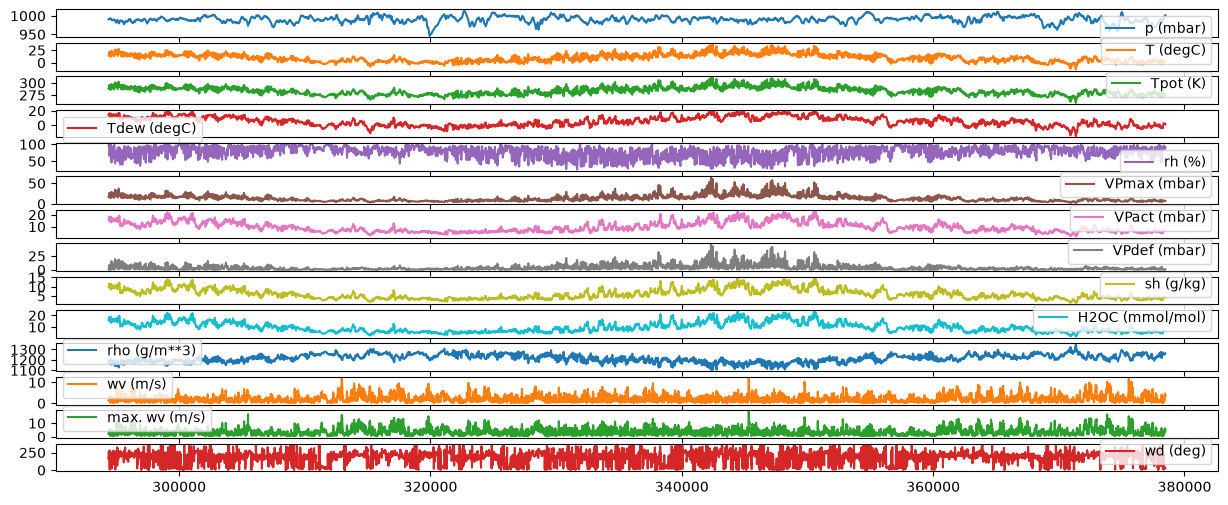

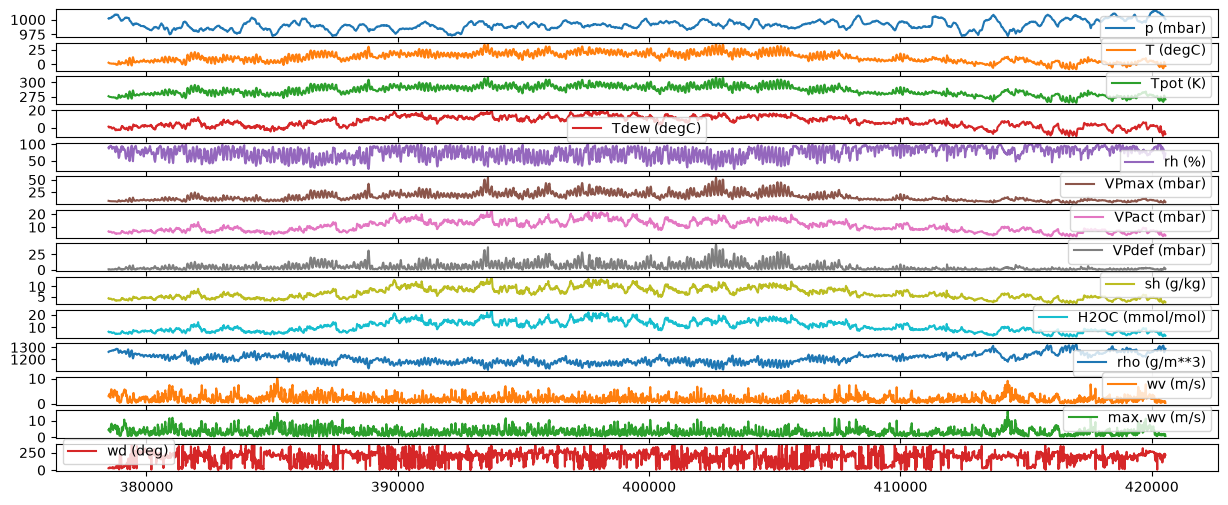

In [69]:
# lets plot the data

train_df.plot(subplots=True)
val_df.plot(subplots=True)
test_df.plot(subplots=True)

In [70]:
# lets normalize the data
# we will use the mean and standard deviation of the training data to normalize the data
train_mean = train_df.mean()
train_std = train_df.std()

# lets normalize the data using the mean and standard deviation of the training data
train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

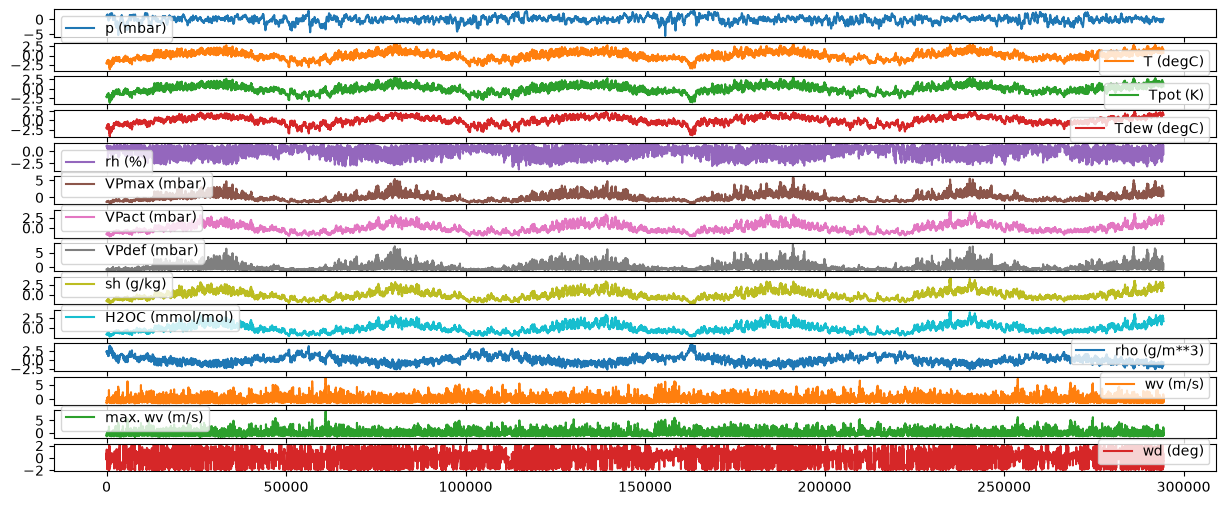

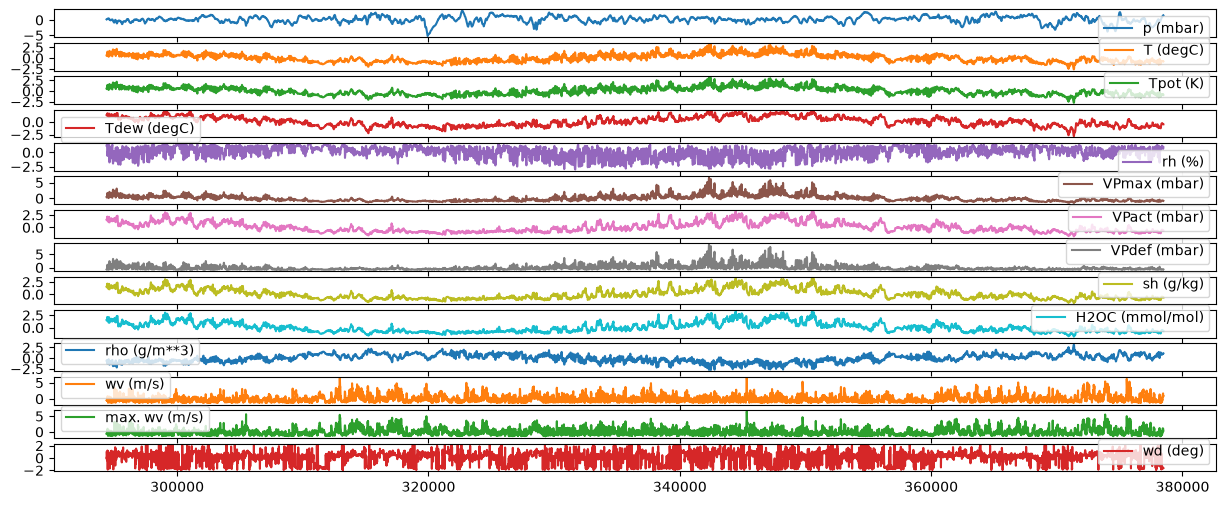

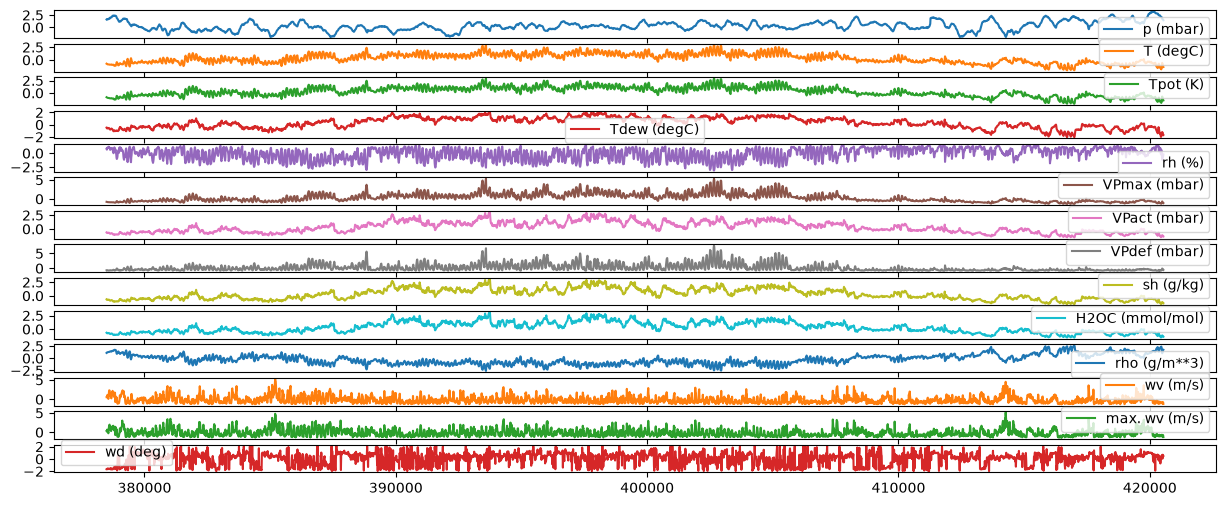

In [71]:
# lets plot the data
train_df.plot(subplots=True)
val_df.plot(subplots=True)
test_df.plot(subplots=True)